# Probabilistic segmentation of ambiguous aerial images with the Probabilistic U-Net

Semantic segmentation assigns a class to every pixel of an image. For some
images, more than one labeling can be considered correct, for example when two
annotators disagree about where a hedge ends or whether a group of trees is
deciduous. In such cases, a model should ideally be able to represent the
different plausible labelings rather than only a single one.

A standard segmentation network predicts a softmax distribution over the
classes at every pixel. These are per-pixel marginal probabilities, whereas a
labeling assigns classes to all pixels jointly. When an annotator labels a
group of trees as one forest type, they usually apply that label to the whole
group. Therefore, a model that predicts each pixel separately can match the
per-pixel class frequencies and still produce labelings that no annotator would
produce. The Probabilistic U-Net (ProbUNet, Kohl et al., 2018) adds a latent
variable that is sampled once per image and shared by all pixels, so that each
sample is a complete labeling of the image.

In this tutorial, we compare a deterministic U-Net with a ProbUNet on
[FLAIR2](https://ignf.github.io/FLAIR/) aerial imagery, loaded through
[GeoBenchV2](https://github.com/microsoft/geobench-v2). To evaluate whether a
model reproduces a distribution of labelings, the true distribution has to be
known. FLAIR2 provides one annotation per tile, so we follow Kohl et al. and
construct the ambiguity ourselves with known probabilities, which allows us to
compare both models against the exact distribution.

## Setup

Both models use Meta's DINOv3 ConvNeXt-B as image encoder, which `timm`
downloads from
[`timm/convnext_base.dinov3_lvd1689m`](https://huggingface.co/timm/convnext_base.dinov3_lvd1689m).
These weights are released under the DINOv3 License and not under the
Apache-2.0 licence of lightning-uq-box, so please check Meta's terms on the
model page before using them in your own work.

The notebook requires a GPU and expects the FLAIR2 data under `FLAIR2_ROOT`.

In [1]:
# Copyright (c) 2023 lightning-uq-box. All rights reserved.
# Licensed under the Apache License 2.0.
# %pip install lightning-uq-box
# %pip install GeoBenchV2 "tacoreader==0.5.6" timm

In [2]:
import itertools
import os
import tempfile
from functools import partial

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import torch
from geobench_v2.datamodules import GeoBenchFLAIR2DataModule
from geobench_v2.datasets import GeoBenchFLAIR2
from lightning import Trainer, seed_everything
from lightning.pytorch.callbacks import Callback, EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from matplotlib.colors import ListedColormap
from safetensors.torch import load_file
from torch import Tensor, nn
from torch.optim.lr_scheduler import LambdaLR
from torchmetrics import JaccardIndex

from lightning_uq_box.eval_utils import (
    generalized_energy_distance,
    hungarian_matched_iou,
)
from lightning_uq_box.uq_methods import DeterministicSegmentation, ProbUNet

seed_everything(0)

DATA_ROOT = os.environ.get("FLAIR2_ROOT", "data/flair2")
IMG_SIZE = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

/path/to/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/path/to/venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


/path/to/venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


2026-09-24 12:43:37,250 - INFO - Asdfghjkl backend not available since the old asdfghjkl dependency is not installed. If you want to use it, run: pip install git+https://git@github.com/wiseodd/asdl@asdfghjkl


[rank: 0] Seed set to 0


## Data: FLAIR2 with constructed ambiguity

FLAIR2 contains 13 land-cover classes on aerial tiles with 0.2 m resolution.
Kohl et al. constructed an ambiguous version of Cityscapes by replacing five
classes with five new classes, each with a fixed probability per image. We
apply the same construction to FLAIR2, which increases the number of classes
from 13 to 18:

| base class | flips to | probability |
|---|---|---:|
| `deciduous` | `deciduous 2` | 8/17 |
| `brushwood` | `brushwood 2` | 7/17 |
| `herbaceous vegetation` | `herbaceous vegetation 2` | 6/17 |
| `agricultural land` | `agricultural land 2` | 5/17 |
| `impervious surface` | `impervious surface 2` | 4/17 |

The five flips are independent of each other, so each tile has 2^5 = 32
possible labelings, which we refer to as **modes**. The probability of a mode
is the product of the five flip probabilities, ranging from 10.88% if no class
is flipped to 0.47% if all classes are flipped. We chose the pairs based on
ambiguities that are documented in the FLAIR annotation guidelines. For
example, `brushwood` and `deciduous` are distinguished by a 5 m height
threshold that is not visible in RGB imagery, and FLAIR includes a separate
"ligneous" class for trees whose type could not be determined during
photo-interpretation.

The construction has three properties that are relevant for the rest of this
tutorial:

- **A flip applies to the whole tile.** If `deciduous` is flipped, all
  `deciduous` pixels in the tile are labeled `deciduous 2`. Therefore, a
  labeling that contains both `deciduous` and `deciduous 2` never occurs in the
  ground truth.
- **A flip introduces a new class** instead of reusing an existing one. As a
  result, the mode of any labeling can be determined from the label map alone.
- **A flip is independent of the image content.** Whether a tile was flipped
  cannot be inferred from its pixels, so a model can at best learn how often
  each flip occurs.

During training, a new mode is sampled each time a tile is loaded, so the
models see each tile with different modes over the course of training. For
validation and test, one mode per tile is sampled with a random generator
seeded by the tile index, so that the evaluation is reproducible.

In [3]:
FLIPS = (
    (6, 13, 8 / 17),  # deciduous
    (7, 14, 7 / 17),  # brushwood
    (9, 15, 6 / 17),  # herbaceous vegetation
    (10, 16, 5 / 17),  # agricultural land
    (2, 17, 4 / 17),  # impervious surface
)
BASE_CLASSES = GeoBenchFLAIR2.classes
NUM_CLASSES = len(BASE_CLASSES) + len(FLIPS)
CLASSES = BASE_CLASSES + tuple(f"{BASE_CLASSES[b]} 2" for b, _, _ in FLIPS)


def apply_mode(mask: Tensor, mode: tuple[int, ...]) -> Tensor:
    out = mask.clone()
    for bit, (base, variant, _) in zip(mode, FLIPS):
        if bit:
            out[mask == base] = variant
    return out


class AmbiguousLabels(nn.Module):
    def __init__(self, resample: bool, seed: int = 0) -> None:
        super().__init__()
        self.resample, self.seed = resample, seed

    def forward(self, sample: dict[str, Tensor]) -> dict[str, Tensor]:
        if self.resample:
            draws = torch.rand(len(FLIPS))
        else:
            gen = torch.Generator().manual_seed(
                self.seed * 1_000_003 + int(sample["index"])
            )
            draws = torch.rand(len(FLIPS), generator=gen)
        mode = tuple(int(d < p) for d, (_, _, p) in zip(draws, FLIPS))
        sample["mask"] = apply_mode(sample["mask"], mode)
        return sample


class Then(nn.Module):
    def __init__(self, first: nn.Module, second: nn.Module) -> None:
        super().__init__()
        self.first, self.second = first, second

    def forward(self, sample: dict[str, Tensor]) -> dict[str, Tensor]:
        return self.second(self.first(sample))


class IndexedFLAIR2(GeoBenchFLAIR2):
    def __init__(self, *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self._sample_transforms, self.transforms = self.transforms, None

    def __getitem__(self, idx: int) -> dict[str, Tensor]:
        sample = super().__getitem__(idx)
        sample["index"] = torch.tensor(idx)
        if self._sample_transforms is not None:
            sample = self._sample_transforms(sample)
        return sample


class AmbiguousFLAIR2DataModule(GeoBenchFLAIR2DataModule):
    def __init__(self, *args, seed: int = 0, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.seed = seed
        self.dataset_class = IndexedFLAIR2

    def setup_image_size_transforms(self):
        train, val, test = super().setup_image_size_transforms()
        return (
            Then(train, AmbiguousLabels(resample=True, seed=self.seed)),
            Then(val, AmbiguousLabels(resample=False, seed=self.seed)),
            Then(test, AmbiguousLabels(resample=False, seed=self.seed)),
        )

    def setup(self, stage: str) -> None:
        super().setup(stage)
        self.num_classes, self.class_names = NUM_CLASSES, CLASSES

In [4]:
datamodule = AmbiguousFLAIR2DataModule(
    img_size=IMG_SIZE,
    band_order={"aerial": ["red", "green", "blue"]},
    batch_size=16,
    eval_batch_size=32,
    num_workers=8,
    pin_memory=True,
    train_augmentations="default",
    eval_augmentations="default",
    root=DATA_ROOT,
    download=False,
    seed=0,
)
datamodule.setup("fit")
datamodule.setup("test")
assert datamodule.num_classes == NUM_CLASSES
print(
    f"train {len(datamodule.train_dataset)} | "
    f"val {len(datamodule.val_dataset)} | test {len(datamodule.test_dataset)} tiles"
)
test_batch = next(iter(datamodule.test_dataloader()))

Initializing normalizer from class: ZScoreNormalizer
Initializing normalizer from class: ZScoreNormalizer
Initializing normalizer from class: ZScoreNormalizer
train 4049 | val 1022 | test 3022 tiles


In the colormap below, each flipping class and its variant have the same hue,
with a darker shade for the base class and a lighter shade for the variant.
The figure shows the tile from the first test batch that contains the most
flipping classes, here all five, under 7 of its 32 modes.

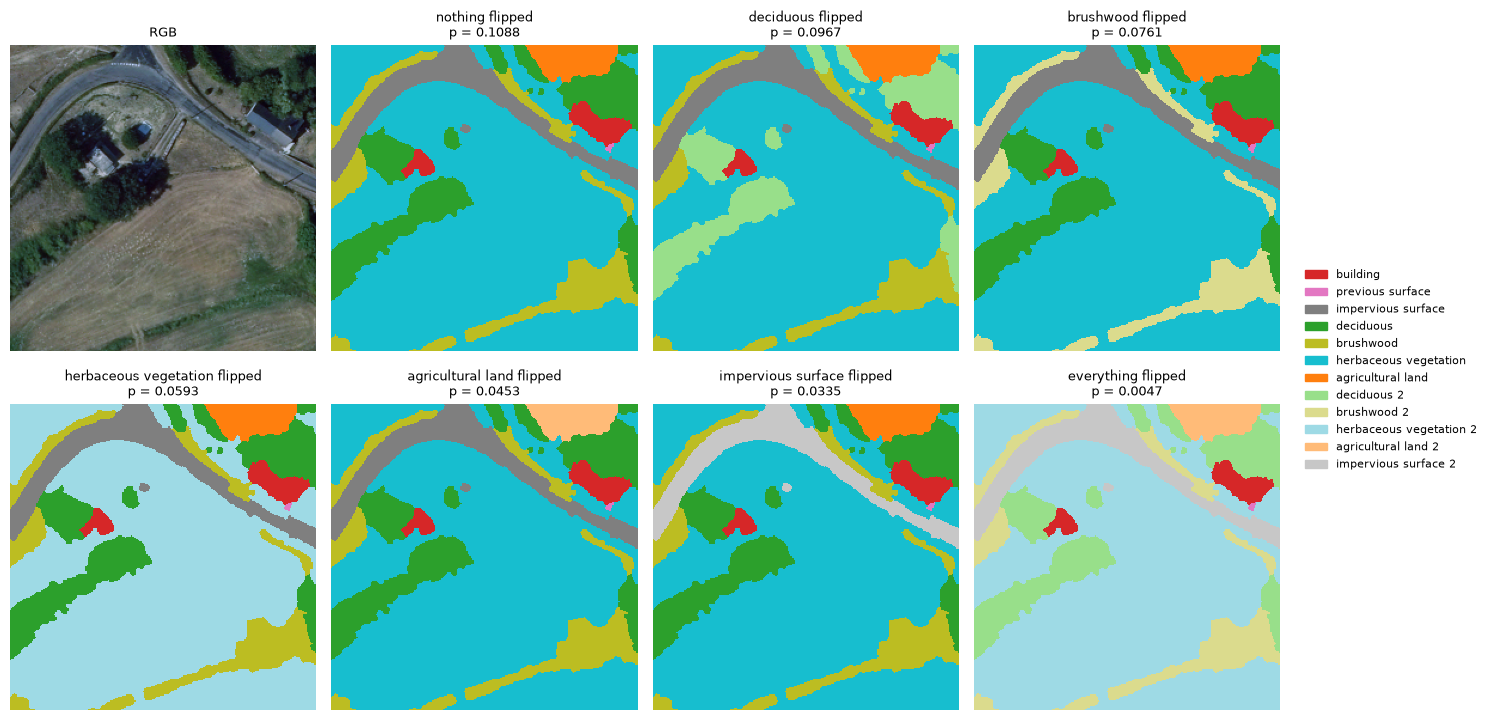

In [5]:
_tab20, _tab20b = plt.cm.tab20.colors, plt.cm.tab20b.colors
_colors = [None] * NUM_CLASSES
for (base, variant, _), hue in zip(FLIPS, (4, 16, 18, 2, 14)):
    _colors[base], _colors[variant] = _tab20[hue], _tab20[hue + 1]
for c, color in zip(
    (0, 1, 3, 4, 5, 8, 11, 12),
    (
        _tab20[6],
        _tab20[12],
        _tab20[10],
        _tab20[0],
        _tab20b[4],
        _tab20[8],
        _tab20b[8],
        "#3b3b3b",
    ),
):
    _colors[c] = color
CMAP = ListedColormap(_colors)


def show_labels(ax, mask: Tensor, title: str = "") -> None:
    ax.imshow(
        mask.cpu(), cmap=CMAP, vmin=0, vmax=NUM_CLASSES - 1, interpolation="nearest"
    )
    ax.set_title(title, fontsize=9)
    ax.axis("off")


def show_rgb(ax, image: Tensor, title: str = "") -> None:
    rgb = image.cpu().movedim(0, -1).float()
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    ax.imshow(rgb)
    ax.set_title(title, fontsize=9)
    ax.axis("off")


def class_legend(fig, masks: Tensor, **kwargs) -> None:
    present = sorted(set(torch.unique(masks.cpu()).tolist()))
    handles = [mpatches.Patch(color=_colors[c], label=CLASSES[c]) for c in present]
    fig.legend(handles=handles, fontsize=8, frameon=False, **kwargs)


def unflipped(mask: Tensor) -> Tensor:
    out = mask.clone()
    for base, variant, _ in FLIPS:
        out[mask == variant] = base
    return out


base_masks = unflipped(test_batch["mask"])
tile = max(
    range(len(base_masks)),
    key=lambda i: sum(bool((base_masks[i] == base).any()) for base, _, _ in FLIPS),
)
base_mask = base_masks[tile]
shown_modes = [(0,) * 5] + [tuple(int(j == i) for j in range(5)) for i in range(5)]
shown_modes.append((1,) * 5)

fig, axes = plt.subplots(2, 4, figsize=(13, 7.4))
show_rgb(axes[0, 0], test_batch["image_aerial"][tile], "RGB")
for ax, mode in zip(axes.flat[1:], shown_modes):
    prob = np.prod([p if bit else 1 - p for bit, (_, _, p) in zip(mode, FLIPS)])
    flipped = [BASE_CLASSES[b] for bit, (b, _, _) in zip(mode, FLIPS) if bit]
    name = (
        "nothing flipped"
        if not flipped
        else ("everything flipped" if len(flipped) == 5 else f"{flipped[0]} flipped")
    )
    show_labels(ax, apply_mode(base_mask, mode), f"{name}\np = {prob:.4f}")
class_legend(
    fig,
    torch.stack([apply_mode(base_mask, m) for m in shown_modes]),
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
)
plt.tight_layout(h_pad=2.0)
plt.show()
plt.close(fig)

## The deterministic model

As a baseline, we use a U-Net from `segmentation_models_pytorch` trained with
per-pixel cross-entropy. Its encoder is the DINOv3 ConvNeXt-B with **frozen**
pretrained weights, so only the decoder and the segmentation head are trained.
The ProbUNet below uses the same frozen encoder, so both models use identical
image features and only differ in the layers trained on top of them.

Both models are trained with AdamW (learning rate 1e-3, weight decay 0.01), a
two-epoch linear warmup and a cosine decay to zero. The deterministic model is
trained for up to 50 epochs with early stopping after 10 epochs without
improvement, and we keep the checkpoint with the highest validation mIoU.
Training took 16 minutes on one A100 GPU. If `FLAIR2_TRAINED` is set to a
directory that contains `<model>/model.safetensors` and `<model>/metrics.csv`,
the trained weights are loaded from there instead of training the model.

In [6]:
ENCODER = "tu-convnext_base.dinov3_lvd1689m"
WARMUP_EPOCHS = 2
BUDGET = {"Deterministic": (50, 10), "ProbUNet": (100, 0)}
MONITOR = {"Deterministic": ("valJaccard", "max"), "ProbUNet": ("val_loss", "min")}
TRAINED = os.environ.get("FLAIR2_TRAINED", "")
LOG_ROOT = TRAINED or tempfile.mkdtemp()

optimizer = partial(torch.optim.AdamW, lr=1e-3, weight_decay=0.01)


def warmup_cosine(epoch: int, max_epochs: int) -> float:
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    t = (epoch - WARMUP_EPOCHS) / max(1, max_epochs - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * min(1.0, t)))


def lr_scheduler(name: str):
    return partial(
        LambdaLR, lr_lambda=partial(warmup_cosine, max_epochs=BUDGET[name][0])
    )


def make_unet() -> nn.Module:
    return smp.Unet(
        encoder_name=ENCODER,
        encoder_weights="imagenet",
        in_channels=3,
        classes=NUM_CLASSES,
    )


def attach_keys(method):
    method.input_key, method.target_key = "image_aerial", "mask"
    return method


class KeepEncoderEval(Callback):
    def __init__(self, encoder: nn.Module) -> None:
        self.encoder = encoder

    def on_train_batch_start(self, trainer, pl_module, batch, batch_idx) -> None:
        self.encoder.eval()


def make_trainer(name: str, encoder: nn.Module) -> Trainer:
    monitor, mode = MONITOR[name]
    max_epochs, patience = BUDGET[name]
    callbacks = [
        ModelCheckpoint(
            dirpath=os.path.join(LOG_ROOT, name),
            filename="best",
            monitor=monitor,
            mode=mode,
        ),
        KeepEncoderEval(encoder),
    ]
    if patience:
        callbacks.append(EarlyStopping(monitor=monitor, mode=mode, patience=patience))
    return Trainer(
        max_epochs=max_epochs,
        accelerator="gpu",
        devices=1,
        precision="32-true",
        gradient_clip_val=1.0,
        logger=CSVLogger(os.path.join(LOG_ROOT, name)),
        callbacks=callbacks,
        enable_model_summary=False,
    )


def train_or_load(name: str, method) -> str:
    encoder = method.model.encoder.requires_grad_(False).eval()
    pretrained = {k: v.clone() for k, v in encoder.state_dict().items()}
    if TRAINED:
        state = load_file(os.path.join(TRAINED, name, "model.safetensors"))
        missing, unexpected = method.load_state_dict(state, strict=False)
        assert not unexpected
        assert all(k.startswith("model.encoder.") for k in missing)
        log = os.path.join(TRAINED, name, "metrics.csv")
    else:
        trainer = make_trainer(name, encoder)
        trainer.fit(method, datamodule=datamodule)
        best = torch.load(
            trainer.checkpoint_callback.best_model_path,
            map_location="cpu",
            weights_only=False,
        )
        method.load_state_dict(best["state_dict"])
        log = os.path.join(trainer.logger.log_dir, "metrics.csv")
    assert all(torch.equal(v, pretrained[k]) for k, v in encoder.state_dict().items())
    attach_keys(method).to(device).eval()
    return log


deterministic = attach_keys(
    DeterministicSegmentation(
        model=make_unet(),
        loss_fn=nn.CrossEntropyLoss(),
        task="multiclass",
        optimizer=optimizer,
        lr_scheduler=lr_scheduler("Deterministic"),
    )
)
logs = {"Deterministic": train_or_load("Deterministic", deterministic)}

2026-09-24 12:43:45,665 - INFO - Loading pretrained weights from Hugging Face hub (timm/convnext_base.dinov3_lvd1689m)


2026-09-24 12:43:45,737 - INFO - [timm/convnext_base.dinov3_lvd1689m] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


The training loss is averaged over each epoch. The dashed line marks the epoch
of the selected checkpoint.

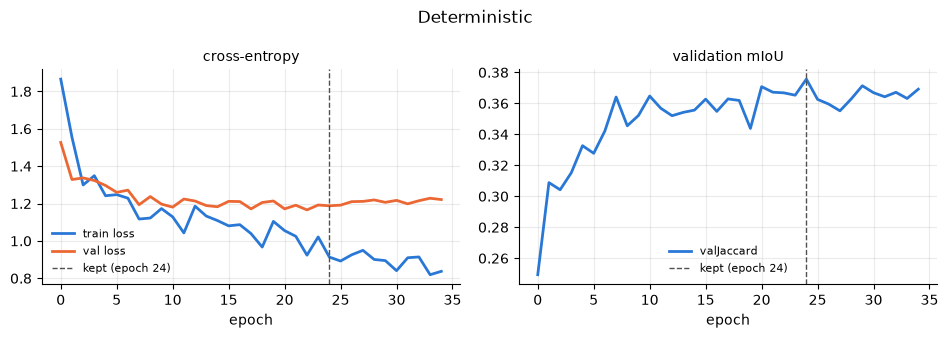

In [7]:
BLUE, ORANGE, AQUA, INK = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"


def plot_learning_curves(name: str, panels: dict[str, list[str]]) -> None:
    per_epoch = pd.read_csv(logs[name]).groupby("epoch").mean(numeric_only=True)
    monitor, mode = MONITOR[name]
    series = per_epoch[monitor].dropna()
    best = series.idxmax() if mode == "max" else series.idxmin()
    fig, axes = plt.subplots(1, len(panels), figsize=(4.8 * len(panels), 3.4))
    for ax, (title, columns) in zip(np.atleast_1d(axes), panels.items()):
        for column, color in zip(columns, (BLUE, ORANGE)):
            values = per_epoch[column].dropna()
            ax.plot(
                values.index,
                values.values,
                color=color,
                lw=2,
                label=column.replace("_", " "),
            )
        ax.axvline(best, color=INK, ls="--", lw=1, label=f"kept (epoch {best})")
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(fontsize=8, frameon=False)
    fig.suptitle(name)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


plot_learning_curves(
    "Deterministic",
    {"cross-entropy": ["train_loss", "val_loss"], "validation mIoU": ["valJaccard"]},
)

### Per-pixel probabilities of the deterministic model

Since a flip cannot be inferred from the image, the optimal per-pixel
prediction on a `deciduous` region is `deciduous 2` with probability 8/17.
Cross-entropy is minimized by the true conditional class frequencies, so a
network trained with it should approximately learn this ratio. To check this
on the whole test split, we compute, for every pixel whose label belongs to a
flipping pair, the softmax probability of the variant relative to the pair,
`p(variant) / (p(base) + p(variant))`, and average it per pair.

In the same loop, we also count how often the argmax labeling contains both
the base class and its variant within one tile, which we call a **mixed**
pair. This never happens in the ground truth.

In [8]:
@torch.no_grad()
def softmax_by_pair() -> pd.DataFrame:
    share = torch.zeros(len(FLIPS), device=device)
    pixels = torch.zeros(len(FLIPS), device=device)
    tiles = torch.zeros(len(FLIPS), device=device)
    mixed = torch.zeros(len(FLIPS), device=device)
    for batch in datamodule.test_dataloader():
        x, y = batch["image_aerial"].to(device), batch["mask"].to(device)
        probs = deterministic.predict_step(x)["pred"]
        labels = probs.argmax(1)
        for f, (base, variant, _) in enumerate(FLIPS):
            in_pair = (y == base) | (y == variant)
            ratio = probs[:, variant] / (probs[:, base] + probs[:, variant])
            share[f] += ratio[in_pair].sum()
            pixels[f] += in_pair.sum()
            has_pair = in_pair.flatten(1).any(1)
            tiles[f] += has_pair.sum()
            both = (labels == base).flatten(1).any(1) & (labels == variant).flatten(
                1
            ).any(1)
            mixed[f] += (both & has_pair).sum()
    return pd.DataFrame(
        {
            "flip probability": [p for _, _, p in FLIPS],
            "mean softmax share of variant": (share / pixels).tolist(),
            "tiles where the argmax mixes the pair": (mixed / tiles).tolist(),
        },
        index=[BASE_CLASSES[b] for b, _, _ in FLIPS],
    ).round(3)


softmax_by_pair()

,flip probability,mean softmax share of variant,tiles where the argmax mixes the pair
deciduous,0.471,0.486,0.946
brushwood,0.412,0.387,0.124
herbaceous vegetation,0.353,0.309,0.000
agricultural land,0.294,0.206,0.000
impervious surface,0.235,0.213,0.000


For four of the five pairs, the average softmax share of the variant is within
0.05 of the flip probability, for example 0.486 compared to 8/17 = 0.471 for
`deciduous`. The exception is `agricultural land` with 0.206 compared to
0.294. Therefore, the per-pixel probabilities of the deterministic model
approximately match the flip probabilities. However, the argmax of these
probabilities is a single labeling, and it mixes `deciduous` and `deciduous 2`
in 94.6% of the tiles that contain this pair, since with a share of 0.486 the
argmax switches between the two classes from pixel to pixel. For the other
four pairs, the share is further below 0.5, so the argmax mostly predicts the
base class and at most 12.4% of tiles are mixed. The figure below shows the
softmax share, the argmax and the softmax entropy for the tile from the data
section.

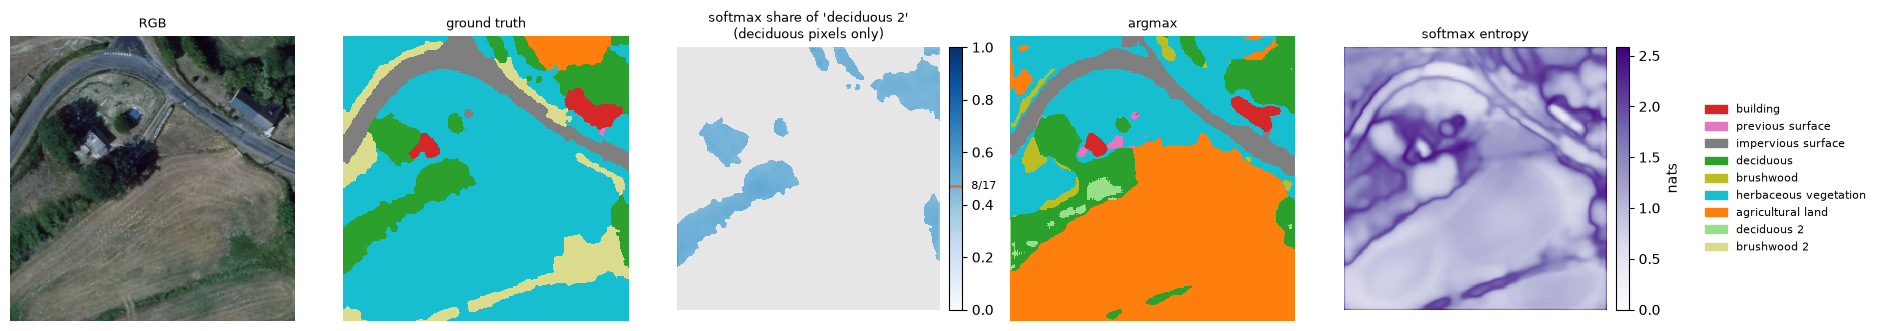

In [9]:
x = test_batch["image_aerial"].to(device)
with torch.no_grad():
    probs = deterministic.predict_step(x)["pred"]
base, variant, p_flip = FLIPS[0]
y = test_batch["mask"][tile].to(device)
ratio = (probs[tile, variant] / (probs[tile, base] + probs[tile, variant])).cpu()
ratio[~((y == base) | (y == variant)).cpu()] = float("nan")

fig, axes = plt.subplots(1, 5, figsize=(17, 3.8))
show_rgb(axes[0], test_batch["image_aerial"][tile], "RGB")
show_labels(axes[1], y, "ground truth")
cmap = plt.cm.Blues.copy()
cmap.set_bad("#e6e6e6")
im = axes[2].imshow(ratio, cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
axes[2].set_title("softmax share of 'deciduous 2'\n(deciduous pixels only)", fontsize=9)
axes[2].axis("off")
bar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.03)
bar.ax.axhline(p_flip, color=ORANGE, lw=2)
bar.ax.text(
    1.4,
    p_flip,
    " 8/17",
    transform=bar.ax.get_yaxis_transform(),
    va="center",
    fontsize=8,
)
show_labels(axes[3], probs[tile].argmax(0), "argmax")
entropy_map = -(probs[tile] * probs[tile].clamp_min(1e-8).log()).sum(0).cpu()
im = axes[4].imshow(entropy_map, cmap="Purples", vmin=0, interpolation="nearest")
axes[4].set_title("softmax entropy", fontsize=9)
axes[4].axis("off")
fig.colorbar(im, ax=axes[4], fraction=0.046, pad=0.03, label="nats")
class_legend(
    fig,
    torch.stack([y.cpu(), probs[tile].argmax(0).cpu()]),
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
)
plt.tight_layout()
plt.show()
plt.close(fig)

## The Probabilistic U-Net

The deterministic model returns one labeling per image, and its softmax
describes each pixel separately. A flip, however, is a single decision for the
whole tile, so producing different valid modes requires a random variable that
is shared by all pixels. ProbUNet adds such a variable, a low-dimensional latent vector `z` that is
sampled once per image and passed to every pixel.

The model consists of four parts:

- **U-Net**: the same frozen encoder and trainable decoder as above, which
  computes a feature map from the image. Its segmentation head is not used
  for predictions.
- **Prior net**: computes a Gaussian distribution over `z` from the image
  alone, with a mean and a standard deviation for each of the 6 latent
  dimensions. At test time, samples are generated by drawing `z` from this
  distribution.
- **Posterior net**: computes a second Gaussian distribution over `z` from the
  image and the ground-truth mask. It is only used during training, where `z`
  is sampled from it, so that the latent can encode which mode the ground
  truth is in.
- **Fcomb**: repeats `z` at every pixel, concatenates it with the decoder
  features and applies several 1×1 convolutions to compute the class logits.
  Since all pixels receive the same `z`, one sample of `z` determines the
  flips for the whole tile.

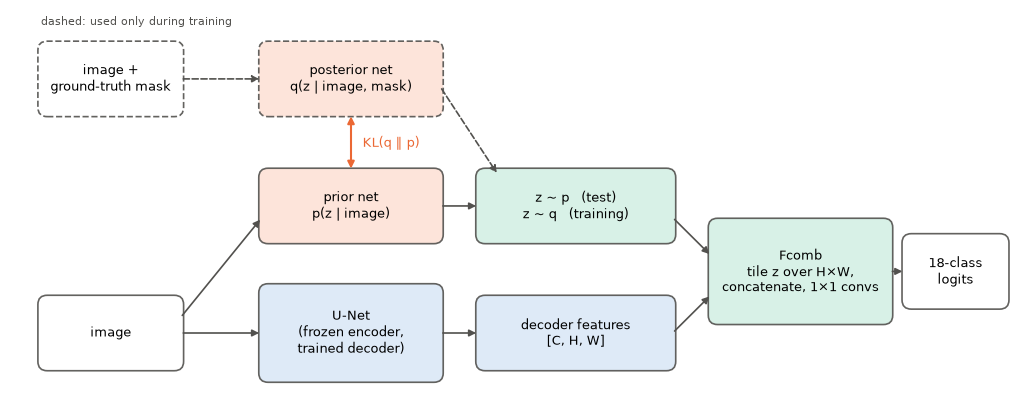

In [10]:
fig, ax = plt.subplots(figsize=(13, 5.2))
ax.set_xlim(0, 13)
ax.set_ylim(0, 5.2)
ax.axis("off")


def box(x, y, text, color, w=2.3, h=0.9, dashed=False):
    ax.add_patch(
        mpatches.FancyBboxPatch(
            (x - w / 2, y - h / 2),
            w,
            h,
            boxstyle="round,pad=0.04,rounding_size=0.12",
            fc=color,
            ec=INK,
            lw=1.2,
            ls="--" if dashed else "-",
            alpha=0.9,
        )
    )
    ax.text(x, y, text, ha="center", va="center", fontsize=9)


def arrow(a, b, dashed=False, text=""):
    ax.annotate(
        "",
        xy=b,
        xytext=a,
        arrowprops={
            "arrowstyle": "-|>",
            "color": INK,
            "lw": 1.2,
            "ls": "--" if dashed else "-",
        },
    )
    if text:
        ax.text(
            (a[0] + b[0]) / 2,
            (a[1] + b[1]) / 2 + 0.15,
            text,
            ha="center",
            fontsize=8,
            color=INK,
        )


box(1.3, 1.0, "image", "#ffffff", w=1.8)
box(1.3, 4.3, "image +\nground-truth mask", "#ffffff", w=1.8, dashed=True)
box(4.4, 1.0, "U-Net\n(frozen encoder,\ntrained decoder)", "#dbe8f7", h=1.2)
box(4.4, 2.65, "prior net\np(z | image)", "#fde2d6")
box(4.4, 4.3, "posterior net\nq(z | image, mask)", "#fde2d6", dashed=True)
box(7.3, 2.65, "z ~ p   (test)\nz ~ q   (training)", "#d4f0e5", w=2.5)
box(7.3, 1.0, "decoder features\n[C, H, W]", "#dbe8f7", w=2.5)
box(10.2, 1.8, "Fcomb\ntile z over H×W,\nconcatenate, 1×1 convs", "#d4f0e5", h=1.3)
box(12.2, 1.8, "18-class\nlogits", "#ffffff", w=1.3)

arrow((2.2, 1.0), (3.25, 1.0))
arrow((2.2, 1.2), (3.25, 2.5))
arrow((2.2, 4.3), (3.25, 4.3), dashed=True)
arrow((5.55, 2.65), (6.05, 2.65))
arrow((5.55, 4.2), (6.3, 3.05), dashed=True)
arrow((5.55, 1.0), (6.05, 1.0))
arrow((8.55, 2.5), (9.05, 2.0))
arrow((8.55, 1.0), (9.05, 1.5))
arrow((11.35, 1.8), (11.55, 1.8))
ax.annotate(
    "",
    xy=(4.4, 3.1),
    xytext=(4.4, 3.85),
    arrowprops={"arrowstyle": "<|-|>", "color": ORANGE, "lw": 1.5},
)
ax.text(4.55, 3.47, "KL(q ‖ p)", color=ORANGE, fontsize=9, va="center")
ax.text(0.4, 5.0, "dashed: used only during training", fontsize=8, color=INK)
plt.show()
plt.close(fig)

Training minimizes the following loss per image:

$$
\mathcal{L} = \frac{1}{HW}\Big[\sum_{i=1}^{HW} \mathrm{CE}\big(\mathrm{Fcomb}(f, z_q)_i,\, y_i\big)
+ \beta\, \mathrm{KL}\big(q(z \mid x, y)\,\|\,p(z \mid x)\big)\Big],
\qquad z_q \sim q(z \mid x, y),
$$

where `x` is the image, `y` the ground-truth mask, `f` the decoder features,
`CE` the cross-entropy at pixel `i`, and `H` and `W` the height and width of
the image. The first term is the reconstruction loss for a latent `z_q`
sampled from the posterior, which has access to the ground truth. The KL term
penalizes differences between posterior and prior, so that samples from the
prior at test time are similar to the latents that the posterior produces
during training. `β` weights the KL term relative to the cross-entropy
**summed** over all pixels, which is the scale used by Kohl et al., so `β = 1`
corresponds to the value in the paper. The division by `HW` only scales the
loss to a per-pixel magnitude and does not change the ratio between the two
terms.

ProbUNet is trained for 100 epochs without early stopping, and we keep the
checkpoint with the lowest validation loss. Training took 67 minutes on one
A100 GPU. The validation mIoU is not suitable for selecting the checkpoint,
because the validation step evaluates reconstructions from the posterior,
which has access to the target.

2026-09-24 12:44:08,164 - INFO - Loading pretrained weights from Hugging Face hub (timm/convnext_base.dinov3_lvd1689m)


2026-09-24 12:44:08,167 - INFO - [timm/convnext_base.dinov3_lvd1689m] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


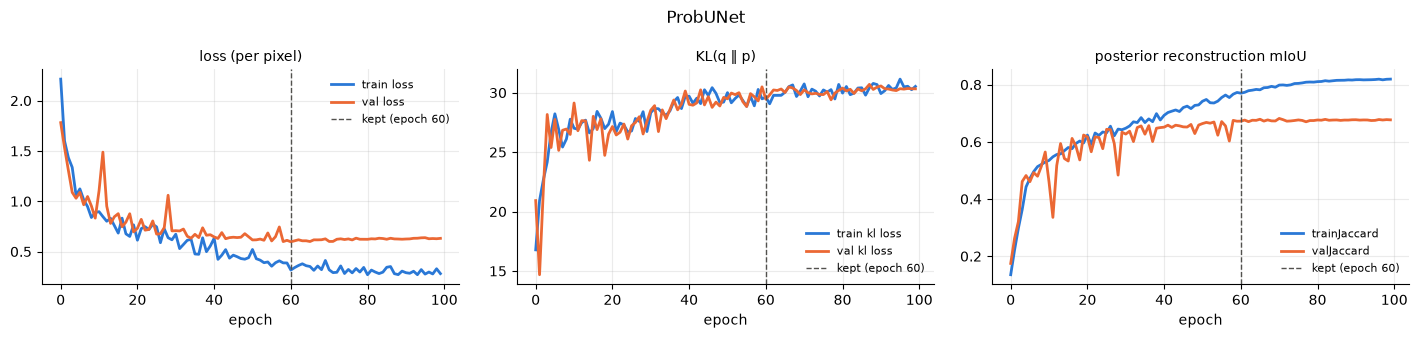

In [11]:
prob_unet = attach_keys(
    ProbUNet(
        model=make_unet(),
        latent_dim=6,
        beta=1.0,
        num_samples=8,
        task="multiclass",
        optimizer=optimizer,
        lr_scheduler=lr_scheduler("ProbUNet"),
    )
)
logs["ProbUNet"] = train_or_load("ProbUNet", prob_unet)
plot_learning_curves(
    "ProbUNet",
    {
        "loss (per pixel)": ["train_loss", "val_loss"],
        "KL(q ‖ p)": ["train_kl_loss", "val_kl_loss"],
        "posterior reconstruction mIoU": ["trainJaccard", "valJaccard"],
    },
)

The KL term increases to about 30 nats early in training and stays at this
level. This indicates that the posterior encodes information about the target
that the prior does not have, i.e., the model makes use of the latent. The
validation mIoU of the posterior reconstructions stays at about 0.68 from
epoch 60 onwards, which is also the epoch with the lowest validation loss,
while the training mIoU continues to increase.

### Determining the mode of a labeling

To compare samples with the 32 modes, we need to determine the mode of each
sampled label map. For each flip, `flip_evidence` checks whether a labeling
contains the base class and whether it contains the variant. A flip is counted
as applied if the variant is present, as not applied if only the base class is
present, and as **unobservable** if neither is present, since for example a
tile without `agricultural land` looks the same with or without that flip. If
unobservable flips were counted as not applied, every measured distribution
would be shifted towards the mode without flips, which is also the most
probable mode, and this bias could be mistaken for good calibration.
`collapse` maps each variant back to its base class, and `mode_probabilities`
returns the analytic probabilities of the 32 modes.

In [12]:
UNOBSERVABLE = -1
MODES = list(itertools.product((0, 1), repeat=len(FLIPS)))


def mode_probabilities() -> np.ndarray:
    return np.array(
        [
            np.prod([p if bit else 1 - p for bit, (_, _, p) in zip(mode, FLIPS)])
            for mode in MODES
        ]
    )


def flip_evidence(masks: Tensor) -> tuple[Tensor, Tensor]:
    has_base = torch.stack([(masks == b).flatten(-2).any(-1) for b, _, _ in FLIPS], -1)
    has_variant = torch.stack(
        [(masks == v).flatten(-2).any(-1) for _, v, _ in FLIPS], -1
    )
    return has_base, has_variant


def mode_of(mask: Tensor) -> tuple[int, ...]:
    has_base, has_variant = flip_evidence(mask)
    return tuple(
        1 if v else 0 if b else UNOBSERVABLE
        for b, v in zip(has_base.tolist(), has_variant.tolist())
    )


def collapse(mask: Tensor) -> Tensor:
    out = mask.clone()
    for base, variant, _ in FLIPS:
        out[mask == variant] = base
    return out


def mode_label(mode: tuple[int, ...]) -> str:
    return "".join("·" if bit == UNOBSERVABLE else str(bit) for bit in mode)


assert abs(mode_probabilities().sum() - 1) < 1e-12

Below are eight samples from the prior for the tile from the data section. The
title of each sample shows its mode as five bits, one per flip in the order of
the table above, where 1 means flipped.

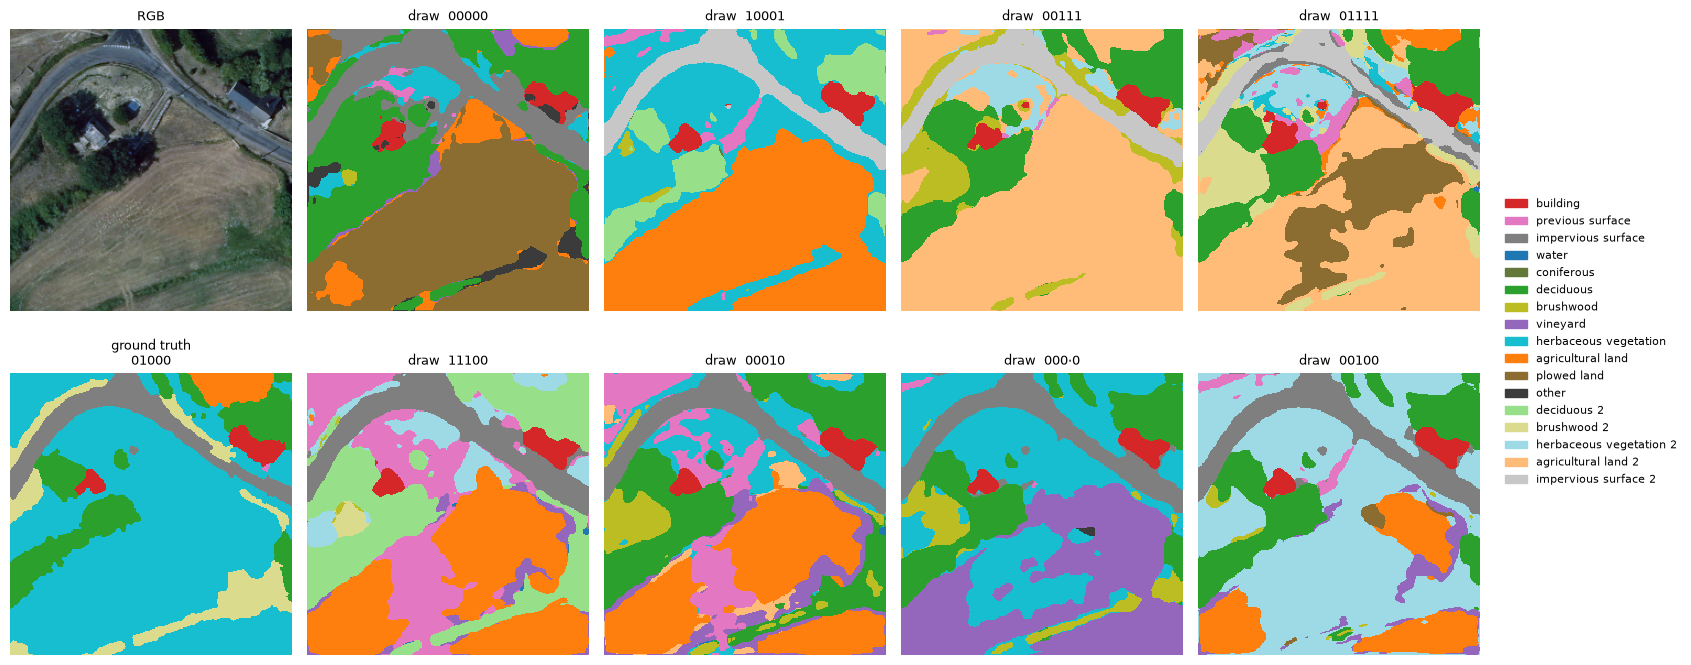

In [13]:
@torch.no_grad()
def prior_draws(x: Tensor, n: int) -> Tensor:
    saved, prob_unet.num_samples = prob_unet.num_samples, n
    logits = prob_unet.predict_step(x)["logits"]
    prob_unet.num_samples = saved
    return logits.argmax(1).movedim(-1, 1)


draws = prior_draws(x[tile : tile + 1], 8)[0]
fig, axes = plt.subplots(2, 5, figsize=(15, 7.0))
show_rgb(axes[0, 0], test_batch["image_aerial"][tile], "RGB")
show_labels(
    axes[1, 0],
    test_batch["mask"][tile],
    f"ground truth\n{mode_label(mode_of(test_batch['mask'][tile]))}",
)
for ax, draw in zip(axes[:, 1:].flat, draws):
    show_labels(ax, draw, f"draw  {mode_label(mode_of(draw))}")
class_legend(
    fig,
    torch.cat([draws.cpu(), test_batch["mask"][tile][None]]),
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
)
plt.tight_layout(h_pad=2.0)
plt.show()
plt.close(fig)

Each sample is a spatially consistent labeling. However, the samples for
this tile differ from each other much more than the five flips alone would
explain. The large field is labeled as `herbaceous vegetation`, `agricultural
land`, `plowed land` or `vineyard` in different samples, whereas the
construction only replaces a base class with its variant and never changes one
base class into another. The sample that labels most of the field as
`vineyard` contains neither `agricultural land` nor its variant, so this flip
cannot be determined and is marked with `·`. We come back
to such samples in the comparison below.

## Comparing the two models

We compare the labelings of the two models:

- **Deterministic**: the argmax of the softmax, which gives the same labeling
  every time.
- **ProbUNet**: one sample from the prior, decoded and converted to a labeling
  with the argmax. We use a single prior sample per labeling, because
  `predict_step` averages the softmax over several samples for its `pred`
  output, and the argmax of this average moves each flip towards its more
  probable value.

In [14]:
PREDICTORS = {"Deterministic": BLUE, "ProbUNet": AQUA}


@torch.no_grad()
def draw_labelings(x: Tensor, n: int) -> dict[str, Tensor]:
    probs = deterministic.predict_step(x)["pred"]
    return {
        "Deterministic": probs.argmax(1, keepdim=True).expand(-1, n, -1, -1),
        "ProbUNet": prior_draws(x, n),
    }


gallery = [
    i
    for i, m in enumerate(test_batch["mask"])
    if sum(mode_of(m)[f] != UNOBSERVABLE for f in range(len(FLIPS))) >= 3
][:4]
gallery_draws = draw_labelings(x[gallery], 3)

### Example test tiles

Each row shows a test tile that contains at least three of the five flipping
classes, with the ground-truth mode in the title. The third column shows the
deterministic argmax, and the last three columns show three ProbUNet samples
with their modes.

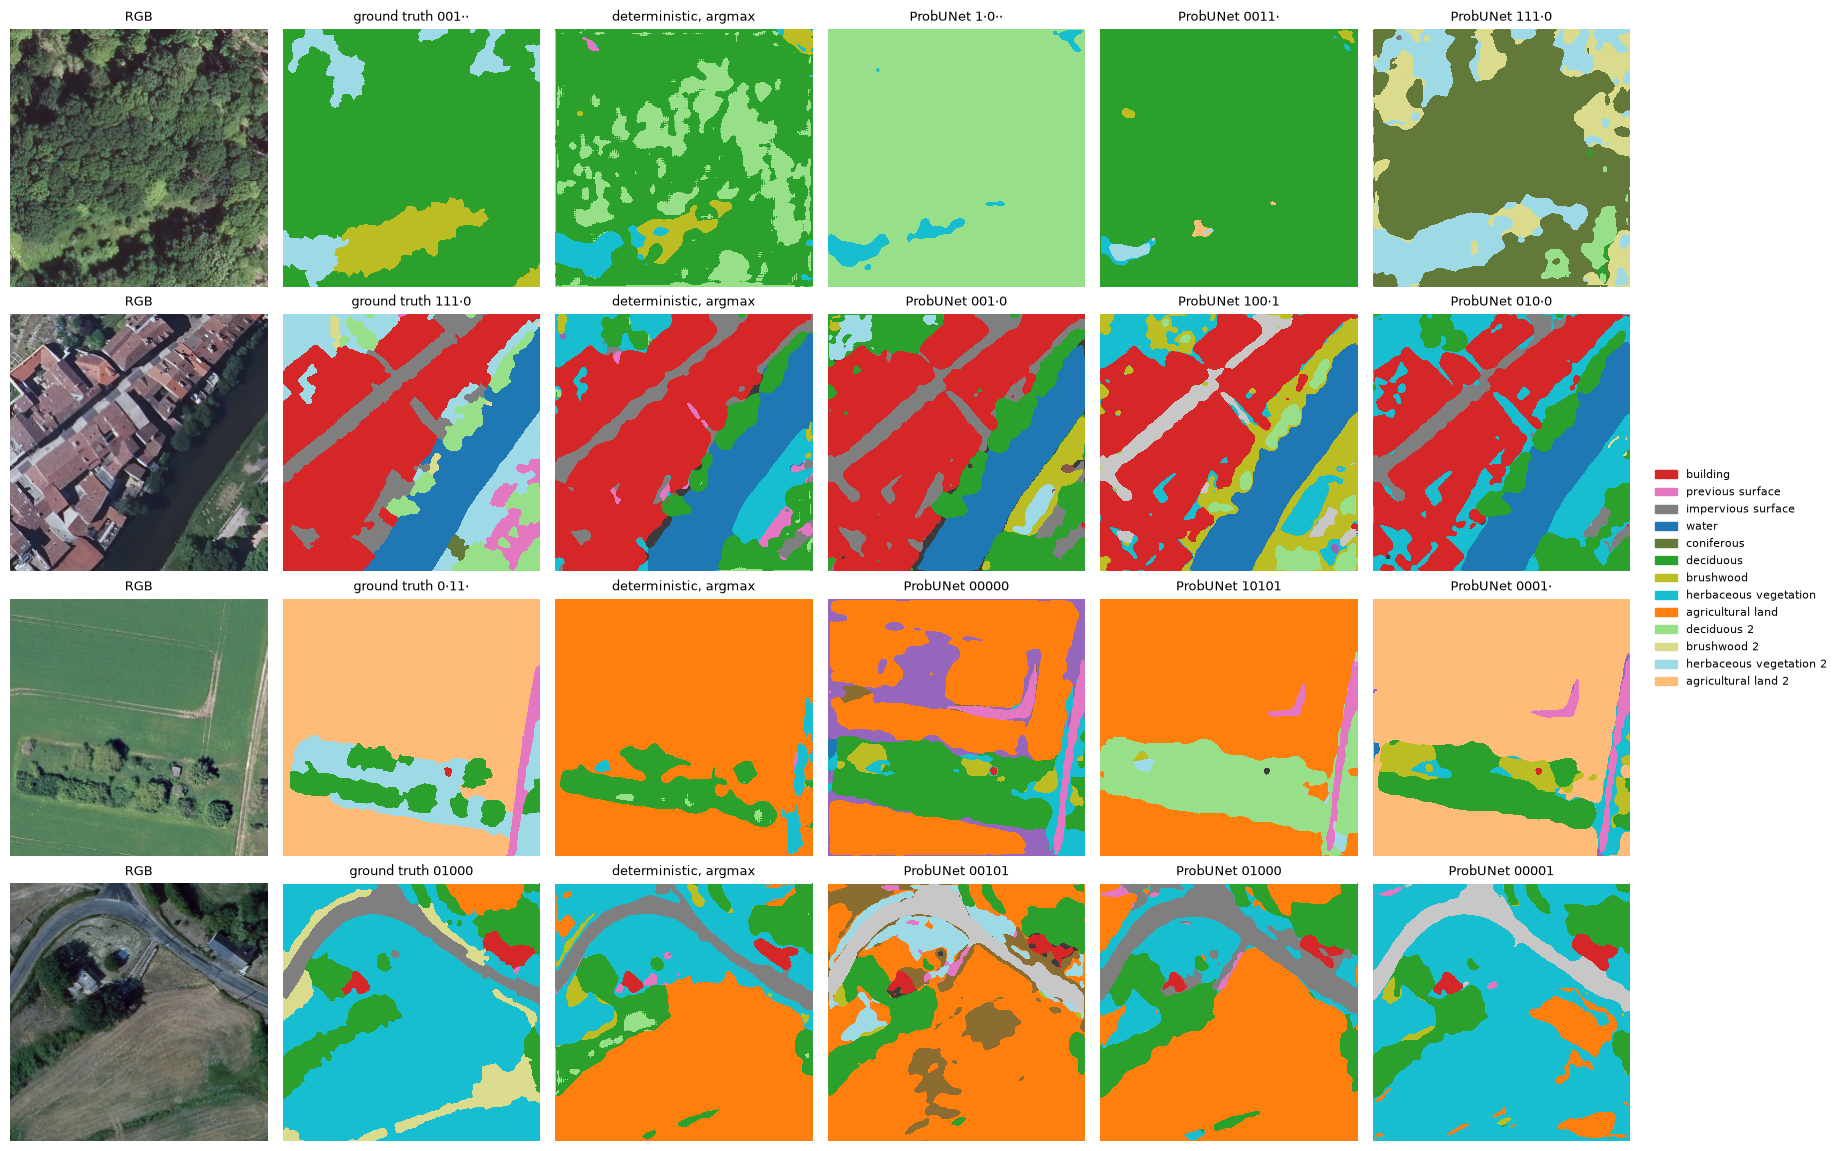

In [15]:
fig, axes = plt.subplots(len(gallery), 6, figsize=(16.5, 2.9 * len(gallery)))
for row, i in enumerate(gallery):
    show_rgb(axes[row, 0], test_batch["image_aerial"][i], "RGB")
    show_labels(
        axes[row, 1],
        test_batch["mask"][i],
        f"ground truth {mode_label(mode_of(test_batch['mask'][i]))}",
    )
    show_labels(
        axes[row, 2], gallery_draws["Deterministic"][row, 0], "deterministic, argmax"
    )
    for k in range(3):
        draw = gallery_draws["ProbUNet"][row, k]
        show_labels(axes[row, 3 + k], draw, f"ProbUNet {mode_label(mode_of(draw))}")
class_legend(
    fig, test_batch["mask"][gallery], loc="center left", bbox_to_anchor=(1.0, 0.5)
)
plt.tight_layout()
plt.show()
plt.close(fig)

In the first row, the ground truth labels the forest as `deciduous`
throughout. The deterministic argmax contains patches of `deciduous 2` within
the forest, which does not correspond to any mode. In contrast, the first
ProbUNet sample labels almost the whole forest as `deciduous 2` and the second
almost the whole forest as `deciduous`, while the third labels most of it as
`coniferous` and `brushwood 2`. The
last row shows the tile from the ProbUNet section again, where the samples also
change the class of the large field between different base classes.

### Entropy maps

The predictive entropy is a common per-pixel uncertainty measure. For the
deterministic model, it is the entropy of the softmax. For ProbUNet, it is the
entropy of the softmax averaged over 8 prior samples, which can be decomposed
into the average entropy of a single sample and the mutual information between
the prediction and the latent. The mutual information is high at pixels where
different samples of `z` lead to different predictions, so it indicates which
pixels are affected by the latent.

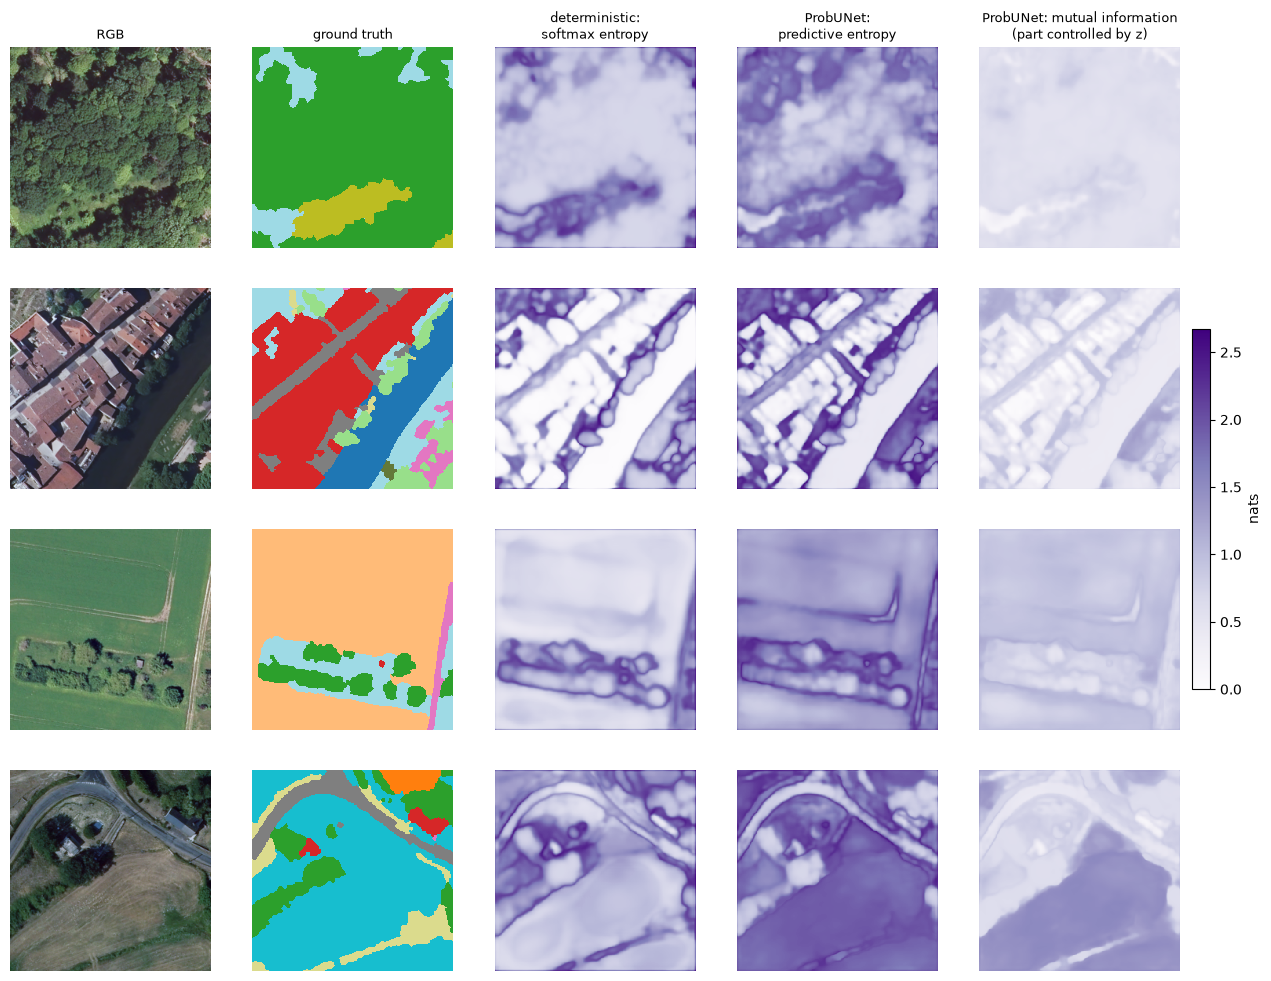

In [16]:
def entropy(p: Tensor, dim: int = 1) -> Tensor:
    return -(p * p.clamp_min(1e-8).log()).sum(dim)


with torch.no_grad():
    det_probs = deterministic.predict_step(x[gallery])["pred"]
    draw_probs = prob_unet.predict_step(x[gallery])["logits"].softmax(1)
maps = {
    "deterministic:\nsoftmax entropy": entropy(det_probs),
    "ProbUNet:\npredictive entropy": entropy(draw_probs.mean(-1)),
    "ProbUNet: mutual information\n(part controlled by z)": entropy(draw_probs.mean(-1))
    - entropy(draw_probs).mean(-1),
}
vmax = max(float(m.max()) for m in maps.values())
fig, axes = plt.subplots(len(gallery), 5, figsize=(15.5, 3 * len(gallery)))
for row, i in enumerate(gallery):
    show_rgb(axes[row, 0], test_batch["image_aerial"][i], "RGB" if row == 0 else "")
    show_labels(axes[row, 1], test_batch["mask"][i], "ground truth" if row == 0 else "")
    for col, (title, values) in enumerate(maps.items(), start=2):
        im = axes[row, col].imshow(
            values[row].cpu(),
            cmap="Purples",
            vmin=0,
            vmax=vmax,
            interpolation="nearest",
        )
        axes[row, col].set_title(title if row == 0 else "", fontsize=9)
        axes[row, col].axis("off")
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01, label="nats")
plt.show()
plt.close(fig)

In these four tiles, the total entropy maps of the two models are similar.
Both models have the highest uncertainty along class boundaries and on the
vegetation classes, and the values of ProbUNet are slightly higher overall.
The mutual information is low and distributed over the whole tile instead of
being concentrated on the flipping classes. This is consistent with the
samples above, in which the latent changes the class of entire fields and not
only the five flipping classes. However, per-pixel maps cannot show whether
the samples are consistent labelings, because each pixel is summarized
separately. The following sections therefore evaluate whole samples.

### mIoU under the constructed ambiguity

The mean intersection over union (mIoU) over all 18 classes is the standard
segmentation metric, which we compute over the whole test split. With the constructed ambiguity, the maximum achievable
mIoU is well below 1. Since a flip cannot be inferred from the image, the
prediction with the highest expected per-pixel accuracy always chooses the
more probable class of each pair, which is the base class for all five pairs.
We compute the score of this prediction by using the collapsed ground truth as
the prediction. In addition, we report the **collapsed** mIoU, for which every
variant is mapped back to its base class in both prediction and target, so
that it measures the segmentation quality on the original 13 classes
independently of the flips.

In [17]:
@torch.no_grad()
def miou_table() -> pd.DataFrame:
    rows = (
        "Deterministic, argmax",
        "ProbUNet, argmax of the 8-draw mean",
        "ProbUNet, single draw",
        "ceiling: always predict the base class",
    )
    full = {
        r: JaccardIndex(task="multiclass", num_classes=NUM_CLASSES).to(device)
        for r in rows
    }
    base = {
        r: JaccardIndex(task="multiclass", num_classes=len(BASE_CLASSES)).to(device)
        for r in rows
    }
    for batch in datamodule.test_dataloader():
        x, y = batch["image_aerial"].to(device), batch["mask"].to(device).long()
        probs = deterministic.predict_step(x)["pred"]
        pu = prob_unet.predict_step(x)
        preds = dict(
            zip(
                rows,
                (
                    probs.argmax(1),
                    pu["pred"].argmax(1),
                    pu["logits"][..., 0].argmax(1),
                    collapse(y),
                ),
            )
        )
        for r, pred in preds.items():
            full[r].update(pred, y)
            base[r].update(collapse(pred), collapse(y))
    ceiling = float(full[rows[-1]].compute())
    return pd.DataFrame(
        {
            r: {
                "mIoU (18 classes)": float(full[r].compute()),
                "fraction of ceiling": float(full[r].compute()) / ceiling,
                "collapsed mIoU (13 classes)": float(base[r].compute()),
            }
            for r in rows
        }
    ).T.round(4)


miou_table()

,mIoU (18 classes),fraction of ceiling,collapsed mIoU (13 classes)
"Deterministic, argmax",0.3356,0.5383,0.5158
"ProbUNet, argmax of the 8-draw mean",0.2954,0.4737,0.4437
"ProbUNet, single draw",0.2465,0.3953,0.3711
ceiling: always predict the base class,0.6235,1.0000,1.0000


The upper bound is 0.6235, so even a model that segments all base classes
perfectly reaches only 0.62 on the 18-class metric. The deterministic argmax
has the highest mIoU with 0.3356, and a single ProbUNet sample the lowest with
0.2465, while the distribution metrics in the next section rank ProbUNet
first. Part of this difference is expected, because a sample that follows the
flip probabilities predicts the less probable class of a pair on some tiles,
which lowers the IoU. Averaging 8 samples before the argmax moves each flip
towards its more probable value and increases the ProbUNet mIoU to 0.2954.
However, the flips do not explain the whole difference, since ProbUNet also
has a lower collapsed mIoU, 0.4437 compared to 0.5158, which means that its
segmentation of the 13 base classes is also less accurate. Therefore, mIoU
favors predicting the most probable labeling and does not measure whether a
model represents the distribution of labelings.

### Flip rates and the distribution over the 32 modes

For each test tile, we draw 16 labelings from each model and determine the
flips in each labeling. For the deterministic model, the 16 labelings are
identical. From these, we compute two summaries:

- **Per-flip rates**: how often each flip occurs, compared to its true
  probability. Only flips that are observable in the ground truth are counted.
  If a sample contains neither class of a pair, it is excluded for that pair,
  since this is a segmentation error and not information about the flip rate.
- **Distribution over the 32 modes**: computed on tiles where all five flips
  are observable, and summarized by the total variation distance (TVD) to the
  analytic distribution. The TVD is half the sum of the absolute differences
  between the two distributions, so it is 0 for identical distributions and 1
  for distributions without overlap.

A sample on a fully observable tile that contains neither class of some pair
has no mode and is excluded from the histogram. The table reports the fraction
of these **unassignable** samples. It also reports the fraction of **mixed**
pairs, i.e., pairs for which a sample contains both classes. A mixed pair is
counted as flipped, because the sample contains the variant, although no mode
contains both classes. In the same loop, we also compute the metrics of the
next section on the first 24 batches (768 tiles).

In [18]:
N_DRAWS = 16
N_GRID = (1, 2, 4, 8, 16)
GED_BATCHES = 24


@torch.no_grad()
def score_distributions() -> dict[str, dict]:
    bit_weights = 2 ** torch.arange(len(FLIPS) - 1, -1, -1, device=device)
    assert [
        int((torch.tensor(m, device=device) * bit_weights).sum()) for m in MODES
    ] == list(range(len(MODES)))
    zeros = partial(torch.zeros, len(FLIPS), device=device)
    stats = {
        name: {
            "fired": zeros(),
            "shown": zeros(),
            "mixed": zeros(),
            "joint": torch.zeros(len(MODES), device=device),
            "unassignable": 0,
            "curves": {n: [] for n in N_GRID},
        }
        for name in PREDICTORS
    }
    for b, batch in enumerate(datamodule.test_dataloader()):
        x, y = batch["image_aerial"].to(device), batch["mask"].to(device).long()
        gt_base, gt_variant = flip_evidence(y)
        observable = (gt_base | gt_variant)[:, None]
        full = observable.all(-1)
        graders = (
            torch.stack([apply_mode(y, m) for m in MODES], 1)
            if b < GED_BATCHES
            else None
        )
        for name, draws in draw_labelings(x, N_DRAWS).items():
            s = stats[name]
            has_base, has_variant = flip_evidence(draws)
            shown = (has_base | has_variant) & observable
            s["fired"] += (has_variant & shown).sum((0, 1))
            s["shown"] += shown.sum((0, 1))
            s["mixed"] += (has_base & has_variant & shown).sum((0, 1))
            assignable = full & shown.all(-1)
            s["unassignable"] += int((full & ~shown.all(-1)).sum())
            codes = (has_variant.long() * bit_weights).sum(-1)[assignable]
            s["joint"] += torch.bincount(codes, minlength=len(MODES))
            if graders is None:
                continue
            for n in N_GRID:
                ged = generalized_energy_distance(
                    draws[:, :n], graders, NUM_CLASSES, ignore_background=False
                )
                hung = hungarian_matched_iou(
                    draws[:, :n], graders, NUM_CLASSES, ignore_background=False
                )
                s["curves"][n].append(
                    torch.stack([ged["ged"], ged["d_ss"], ged["d_sy"], hung], 1).cpu()
                )
    return stats


stats = score_distributions()
analytic = mode_probabilities()
flip_p = np.array([p for _, _, p in FLIPS])
results, recovered, marginals = {}, {}, {}
for name, s in stats.items():
    joint = s["joint"].cpu().numpy()
    recovered[name] = joint / joint.sum()
    assert abs(recovered[name].sum() - 1) < 1e-9, "histogram does not sum to 1"
    marginals[name] = (s["fired"] / s["shown"]).cpu().numpy()
    at_16 = torch.cat(s["curves"][N_DRAWS]).mean(0)
    results[name] = {
        "TVD (32 modes)": 0.5 * np.abs(recovered[name] - analytic).sum(),
        "mean |flip-rate error|": np.abs(marginals[name] - flip_p).mean(),
        "mixed pairs": float(s["mixed"].sum() / s["shown"].sum()),
        "unassignable draws": s["unassignable"] / (s["unassignable"] + joint.sum()),
        "GED² (16 draws)": float(at_16[0]),
        "d_ss (16 draws)": float(at_16[1]),
        "Hungarian IoU (16 draws)": float(at_16[3]),
    }
pd.DataFrame(results).T.round(4)

,TVD (32 modes),mean |flip-rate error|,mixed pairs,unassignable draws,GED² (16 draws),d_ss (16 draws),Hungarian IoU (16 draws)
Deterministic,0.8724,0.3307,0.3162,0.1872,0.7688,0.0000,0.562
ProbUNet,0.3652,0.0879,0.0521,0.4242,0.3271,0.3959,0.635


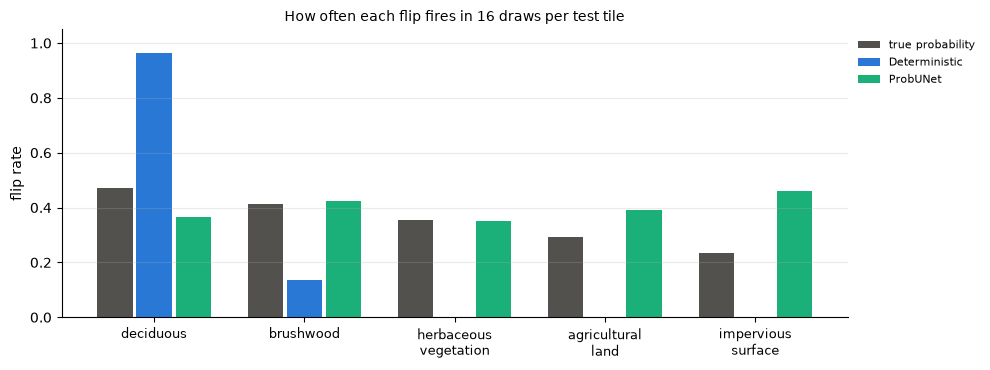

,deciduous,brushwood,herbaceous vegetation,agricultural land,impervious surface
true probability,0.471,0.412,0.353,0.294,0.235
Deterministic,0.965,0.135,0.000,0.000,0.000
ProbUNet,0.365,0.424,0.353,0.391,0.460


In [19]:
fig, ax = plt.subplots(figsize=(10, 3.8))
width = 0.26
xs = np.arange(len(FLIPS))
ax.bar(xs - width, flip_p, width * 0.9, color=INK, label="true probability")
for k, (name, color) in enumerate(PREDICTORS.items()):
    ax.bar(xs + k * width, marginals[name], width * 0.9, color=color, label=name)
ax.set_xticks(xs, [BASE_CLASSES[b].replace(" ", "\n") for b, _, _ in FLIPS], fontsize=9)
ax.set_ylabel("flip rate")
ax.set_ylim(0, 1.05)
ax.set_title("How often each flip fires in 16 draws per test tile", fontsize=10)
ax.grid(alpha=0.25, axis="y")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8, frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()
plt.close(fig)

pd.DataFrame(
    {"true probability": flip_p, **marginals},
    index=[BASE_CLASSES[b] for b, _, _ in FLIPS],
).T.round(3)

ProbUNet's flip rates are within 0.02 of the true probability for `brushwood`
and `herbaceous vegetation`. In contrast, `deciduous` is flipped too rarely
(0.365 compared to 0.471), and `agricultural land` and `impervious surface` are
flipped too often (0.391 compared to 0.294, and 0.460 compared to 0.235). The
deterministic argmax flips `deciduous` in 96.5% of tiles and never flips the
last three classes. Its `deciduous` rate is caused by mixed pairs, since a
labeling with any `deciduous 2` pixel is counted as flipped: 31.6% of the
pairs in the argmax labelings are mixed, compared to 5.2% for ProbUNet.

ProbUNet also has the highest fraction of unassignable samples, 42.4% on fully
observable tiles compared to 18.7% for the argmax. These are samples that
label a whole region with a class outside its pair, as in the samples shown in
the ProbUNet section. Therefore, ProbUNet's histogram below is computed from
the remaining 57.6% of its samples.

The following figure uses the same presentation as Kohl et al.: one bar per
mode, sorted by analytic probability, with the true probability in gray next
to the estimated one. Each panel has its own y-axis scale, so bars should only
be compared within a panel.

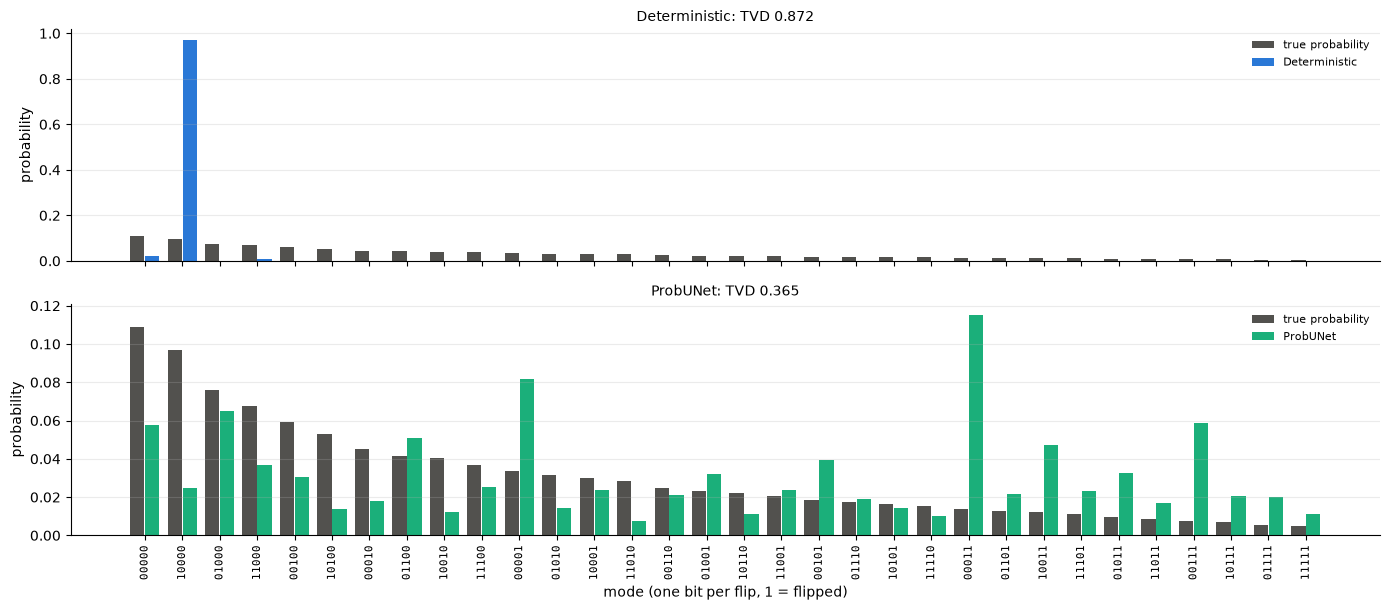

,true probability,Deterministic,ProbUNet
00011,0.014,0.000,0.115
10000,0.097,0.969,0.025
00000,0.109,0.021,0.058
00111,0.008,0.000,0.059
00001,0.033,0.000,0.082
10100,0.053,0.000,0.014


In [20]:
order = np.argsort(-analytic, kind="stable")
fig, axes = plt.subplots(
    len(PREDICTORS), 1, figsize=(14, 3.1 * len(PREDICTORS)), sharex=True
)
xs = np.arange(len(MODES))
for ax, (name, color) in zip(axes, PREDICTORS.items()):
    ax.bar(xs - 0.2, analytic[order], 0.38, color=INK, label="true probability")
    ax.bar(xs + 0.2, recovered[name][order], 0.38, color=color, label=name)
    ax.set_title(f"{name}: TVD {results[name]['TVD (32 modes)']:.3f}", fontsize=10)
    ax.set_ylabel("probability")
    ax.grid(alpha=0.25, axis="y")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8, frameon=False, loc="upper right")
axes[-1].set_xticks(
    xs,
    [mode_label(MODES[i]) for i in order],
    rotation=90,
    fontsize=8,
    family="monospace",
)
axes[-1].set_xlabel("mode (one bit per flip, 1 = flipped)")
plt.tight_layout()
plt.show()
plt.close(fig)

modes = pd.DataFrame(
    {"true probability": analytic, **recovered}, index=[mode_label(m) for m in MODES]
)
largest = (modes["ProbUNet"] - modes["true probability"]).abs().nlargest(6).index
modes.loc[largest].round(3)

ProbUNet's histogram has a TVD of 0.365, compared to 0.872 for the
deterministic argmax. The argmax assigns 97% of its mass to the mode `10000`,
because its mixed `deciduous` pairs are counted as flipped. ProbUNet assigns
mass to all 32 modes, but it underestimates the most probable modes, for example
`00000` with 0.058 compared to 0.109. It also overestimates modes in which
`agricultural land` and `impervious surface` are flipped together, most
strongly `00011` with 0.115 compared to 0.014, which is consistent with the
two flip rates that are too high in the previous figure.

### GED and Hungarian IoU against the number of samples

Two common metrics for comparing a set of sampled labelings with a set of
reference labelings, here the 32 modes of each tile, are the generalized
energy distance (GED) and the Hungarian-matched IoU. The squared GED is

$$
D^2_{\mathrm{GED}} = 2\,\mathbb{E}[d(S, Y)] - \mathbb{E}[d(S, S')] - \mathbb{E}[d(Y, Y')],
$$

where `S` and `S'` are samples of the model, `Y` and `Y'` reference
labelings, and `d = 1 − IoU`. Lower values are better. The middle term,
`d_ss`, measures the diversity among the model's samples and is subtracted, so
a model can reduce its GED by producing more diverse samples without becoming
more accurate. We therefore always report `d_ss` together with GED. The
Hungarian-matched IoU assigns samples and reference labelings one to one such
that the total IoU is maximal, after repeating both sets to a common size, and
reports the mean IoU of the matched pairs, where higher is better. Since all
reference labelings have the same weight while the true modes do not, the
Hungarian IoU measures whether the samples cover the modes, but not whether
they match the mode frequencies.

Both metrics depend on the number of samples `N`. The expectations include
pairs of a sample with itself, which have distance zero, so for small `N` the
diversity `d_ss` is underestimated and GED is overestimated. Comparisons are
therefore only meaningful for the same `N`, which is why the figure below
shows the metrics for `N` from 1 to 16.

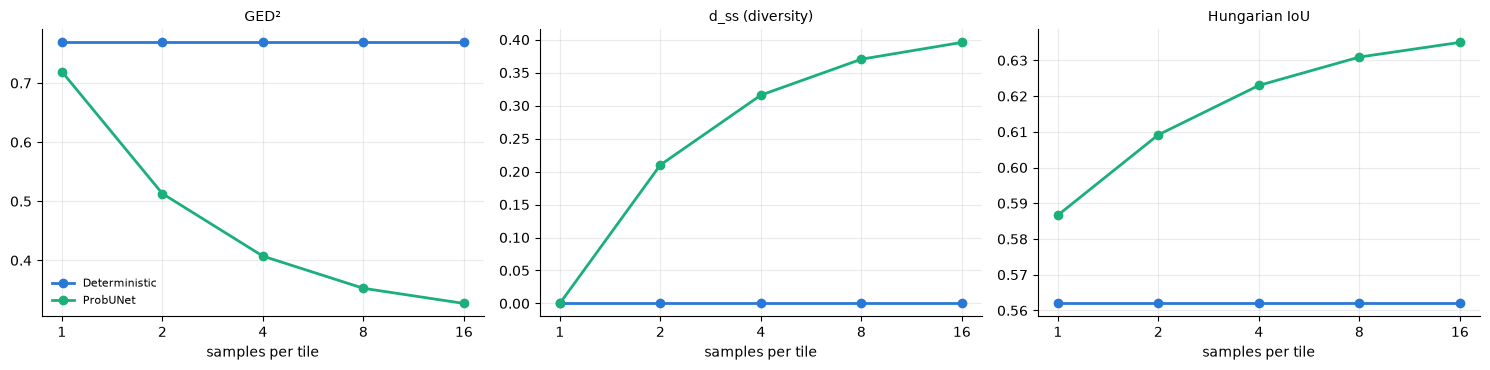

Deterministic               ProbUNet              
                          GED² Hungarian IoU     GED² Hungarian IoU
samples per tile                                                   
1                        0.769         0.562    0.719         0.587
2                        0.769         0.562    0.513         0.609
4                        0.769         0.562    0.407         0.623
8                        0.769         0.562    0.353         0.631
16                       0.769         0.562    0.327         0.635

In [21]:
curve_names = ("GED²", "d_ss (diversity)", "Hungarian IoU")
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for name, color in PREDICTORS.items():
    means = np.array(
        [torch.cat(stats[name]["curves"][n]).mean(0).numpy() for n in N_GRID]
    )
    for ax, column in zip(axes, (0, 1, 3)):
        ax.plot(
            N_GRID, means[:, column], marker="o", ms=6, lw=2, color=color, label=name
        )
for ax, title in zip(axes, curve_names):
    ax.set_xscale("log", base=2)
    ax.set_xticks(N_GRID, [str(n) for n in N_GRID])
    ax.set_xlabel("samples per tile")
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()
plt.close(fig)

pd.DataFrame(
    {
        (name, metric): [
            float(torch.cat(stats[name]["curves"][n]).mean(0)[column]) for n in N_GRID
        ]
        for name in PREDICTORS
        for metric, column in (("GED²", 0), ("Hungarian IoU", 3))
    },
    index=pd.Index(N_GRID, name="samples per tile"),
).round(3)

At 16 samples, ProbUNet has a GED² of 0.327 compared to 0.769 for the
deterministic argmax, and a Hungarian IoU of 0.635 compared to 0.562.
ProbUNet's GED² decreases from 0.72 at one sample to 0.33 at 16 samples,
because the self-pairs have less weight in `d_ss` as `N` increases. In
contrast, the argmax produces the same labeling every time, so its `d_ss` is 0
and its GED² stays at 0.769 for every `N`.

## Limitations

- **One training run per model.** In other runs with the same training setup,
  ProbUNet's TVD varied considerably between seeds: 0.47, 0.34 and 0.21 for
  three seeds at 50 epochs. With 100 epochs and no early stopping, as used
  here, one of three runs learned a latent that the decoder ignores, with a
  sample diversity of 0.036 on the validation split. The TVD of 0.365 in this
  notebook should therefore be interpreted as the result of a single run.
- **ProbUNet does not recover the distribution exactly.** Three of its five
  flip rates deviate from the true probabilities by 0.10 to 0.23, and 42.4% of
  its samples are unassignable, because they label whole regions with a
  different base class.
- **The better distribution comes with a lower mIoU.** A single ProbUNet
  sample reaches 0.2465 mIoU compared to 0.3356 for the deterministic argmax,
  and 0.3711 compared to 0.5158 on the collapsed 13 classes, which do not
  depend on the flips.
- **The constructed ambiguity is simplified.** Each flip is independent of the
  image and applies to the whole tile. In contrast, disagreement between real
  annotators depends on the image content and is often local, for example at
  class boundaries. This notebook does not evaluate how the comparison changes
  in that case.